# Retrieval

In this example, we we fit a model to the simulated data. We assume an isothermal temperature profile and generate transmission spectrum using `SpectralModel`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from petitRADTRANS.spectral_model import SpectralModel
from petitRADTRANS.planet import Planet
from scipy.stats import binned_statistic
import dynesty
from dynesty.utils import resample_equal
from juliet.utils import get_quantiles
from scipy import stats
import astropy.units as u
from tqdm import tqdm
from krithika import plotstyles
import pickle
import seaborn as sns
import corner
import os
from pathlib import Path
from multiprocessing import Pool
import contextlib

import multiprocessing
multiprocessing.set_start_method('fork')

from matplotlib import rcParams
rcParams['figure.dpi'] = 300

In [2]:
# ------------- Output directory -------------
p1 = '/'.join( os.getcwd().split('/')[:-1] )
pout = p1 + '/Retrieval/Analysis/Isothermal/'
if not Path(pout).exists():
    os.mkdir(pout)

# ------------- Loading the planet -------------
toi396b = Planet.get(name='HR 858 b')

Let's now load the data, which we generated using GenTSO in another notebook:

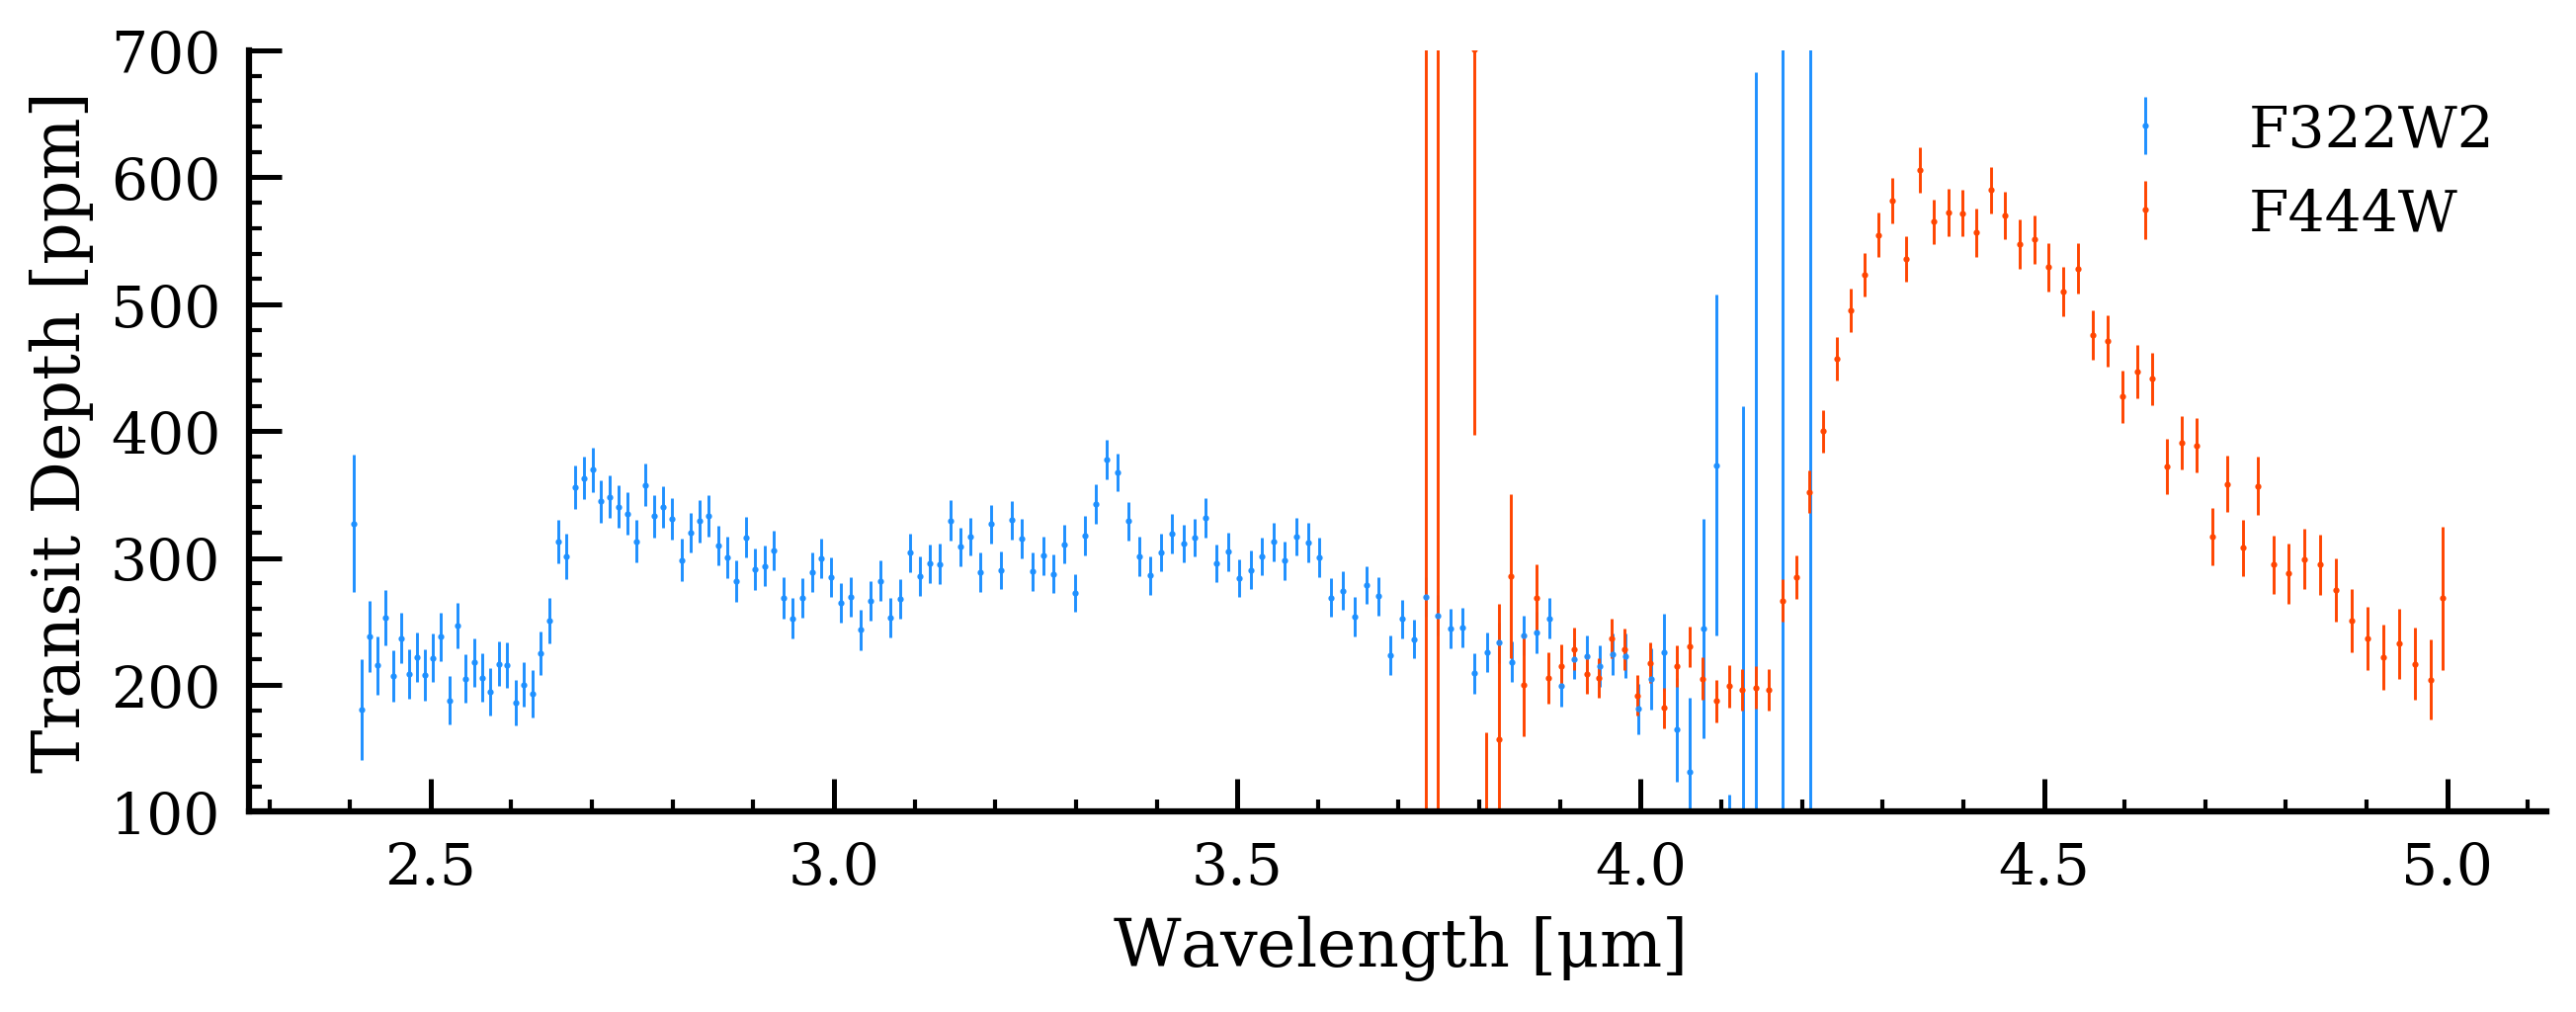

In [3]:
# Loading the data
wav_f322, dep_f322, dep_err_f322 = np.loadtxt(p1 + '/GenTSO/Data/toi396b_transit_spectrum_isothermal_f322w2_R250.txt', usecols=(0,1,2), unpack=True)
wav_f444, dep_f444, dep_err_f444 = np.loadtxt(p1 + '/GenTSO/Data/toi396b_transit_spectrum_isothermal_f444w_R250.txt', usecols=(0,1,2), unpack=True)

# Plotting the data
fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5))
axs.errorbar(wav_f322, dep_f322, yerr=dep_err_f322, fmt='.', markersize=1., elinewidth=0.7, color='dodgerblue', label='F322W2')
axs.errorbar(wav_f444, dep_f444, yerr=dep_err_f444, fmt='.', markersize=1., elinewidth=0.7, color='orangered', label='F444W')

axs.set_xlabel('Wavelength [$\mu$m]')
axs.set_ylabel('Transit Depth [ppm]')

axs.set_ylim([100, 700])

axs.legend()

sns.despine()

Okay, now let's generate the `SpectralModel` and a forward model based on it:

In [4]:
# --------------------------------------------------------------------------------
#.   Initializing the petitRADTRANS SpectralModel object
# This object will be used to compute the model spectra for the retrieval.
# --------------------------------------------------------------------------------

specmodel = SpectralModel(
    # Radtrans parameters
    pressures=np.logspace(-6, 2, 100),
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[1, 6],
    
    # Model parameters
    ## Planet parameters
    planet_radius=toi396b.radius,
    reference_gravity=toi396b.reference_gravity,
    reference_pressure=toi396b.reference_pressure,
    
    ## Temperature profile parameters
    temperature=1000,  # isothermal temperature profile
    
    # Mass fractions
    imposed_mass_fractions={  # these can also be arrays of the same size as pressures
        'CO2': 10e-6,
        'CH4': 10e-6
    },
    filling_species={  # automatically fill the atmosphere with H2 and He, such that the sum of MMRs is equal to 1 and H2/He = 37/12
        'H2': 3.096,
        'He': 1.
    },

    # Opacity mode (line-by-line in this case)
    line_opacity_mode='c-k'

)

# --------------------------------------------------------------------------------
#    Generating the forward model, which can calculate the transit
#.           model and the log-likelihood for the retrieval.
# --------------------------------------------------------------------------------

def gaussian_log_likelihood(residuals, variances):
    taus = 1. / variances
    return -0.5 * (len(residuals) * np.log(2*np.pi) + np.sum(-np.log(taus.astype(float)) + taus * (residuals**2)))

def evaluate_model(wav, dep, dep_err, spec, log_co2, log_ch4, temp, offset, wav_res=None, res_func=None):
    #print('>>> --- Is it at least running? ---')
    # Let's first modify the mass fractions
    spec.model_parameters['imposed_mass_fractions']['CO2'] = 10**log_co2
    spec.model_parameters['imposed_mass_fractions']['CH4'] = 10**log_ch4
    
    # And updating the temperature for an isothermal profile
    spec.model_parameters['temperature'] = temp

    # Calculating the model spectrum
    wave_model, transit_radii_model = spec.calculate_spectrum(
        mode='transmission'
    )
    
    #print('>>> --- Did it calculate the spectrum? ---')
    ## Converting units
    wave_model = ( wave_model[0,:] * u.cm ).to(u.micron).value
    dep_model = ( ( transit_radii_model[0,:] / toi396b.star_radius )**2 ) * 1e6  # converting to ppm

    # --- This model would be at the native resolution of petitRADTRANS, so we need to bin it to the resolution of the data ---
    ## Wavelength boundaries
    wav_diff = np.hstack([ np.diff(wav)[0], np.diff(wav) ])  # calculating the wavelength differences, and adding the last one to keep the same size
    wav_st, wav_end = wav - wav_diff/2, wav + wav_diff/2  # calculating the wavelength boundaries for each data point

    ## Binning the model spectrum to the resolution of the data (vectorized)
    bin_edges = np.append(wav_st, wav_end[-1])
    dep_model_binned, _, _ = binned_statistic(wave_model, dep_model, statistic='mean', bins=bin_edges)

    if res_func is not None and wav_res is not None:
        ## Binning the resolution function to the same wavelength grid as the data (vectorized)
        res_func_binned, _, _ = binned_statistic(wav_res, res_func, statistic='mean', bins=bin_edges)
        ## Multiplying the response function with the binned model spectrum
        dep_model_binned *= res_func_binned

    ## Apply offset
    transit_depth_model = dep_model_binned + offset

    # Calculating the log-likelihood
    residuals = dep - transit_depth_model
    log_likelihood = gaussian_log_likelihood(residuals, dep_err**2)

    #print(log_likelihood, np.where(np.isnan(transit_depth_model)))
    
    return transit_depth_model, log_likelihood

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

Let's load the data, and create `juliet`-like priors and sampling:

In [5]:
# ------------------------------------------------------------------
#
# Defining the data in the format that we will use for the retrieval
#
# ------------------------------------------------------------------
wav, dep, dep_err = {}, {}, {}
wav['F322W2'], dep['F322W2'], dep_err['F322W2'] = wav_f322, dep_f322, dep_err_f322
wav['F444W'], dep['F444W'], dep_err['F444W'] = wav_f444, dep_f444, dep_err_f444


# ------------------------------------------------------------------
#
#                        Defining the priors
#
# ------------------------------------------------------------------
## We will basically fit for four parameters: the log of the mass fractions of CO2 and CH4, and the temperature of the isothermal profile.
#  We will also add an offset parameter to account for any potential systematic offsets in the data.

par = ['logCO2', 'logCH4', 'temp', 'offset_F322W2', 'offset_F444W']
dist = ['uniform', 'uniform', 'uniform', 'fixed', 'uniform']
hypers = [[-10, -1], [-10, -1], [500, 2000], 0., [-100, 100]]

## Prior transform
def uniform(t, a, b):
    return (b-a)*t + a
def stand(a, loc, scale):
    return (a-loc)/scale

# Saving prior file
f11 = open(pout + '/priors.dat', 'w')
for i in range(len(par)):
    f11.write(par[i] + '\t' + dist[i] + '\t' + str(hypers[i]) + '\n')
f11.close()

# First leave the fixed parameters
free_params, free_dists, free_hypers = [], [], []
fixed_params, fixed_vals = [], []
for i in range(len(par)):
    if dist[i] != 'fixed':
        free_params.append(par[i])
        free_dists.append(dist[i])
        free_hypers.append(hypers[i])
    else:
        fixed_params.append(par[i])
        fixed_vals.append(hypers[i])

# Prior cube for only free parameters
def prior_transform(ux):
    x = np.array(ux)
    for i in range(len(free_params)):
        if free_dists[i] == 'uniform':
            x[i] = uniform(ux[i], free_hypers[i][0], free_hypers[i][1])
        elif free_dists[i] == 'normal':
            x[i] = stats.norm.ppf(ux[i], loc=free_hypers[i][0], scale=free_hypers[i][1])
        elif free_dists[i] == 'truncatednormal':
            x[i] = stats.truncnorm.ppf(ux[i], a=stand(free_hypers[i][2], free_hypers[i][0], free_hypers[i][1]), b=stand(free_hypers[i][3], free_hypers[i][0], free_hypers[i][1]), loc=free_hypers[i][0], scale=free_hypers[i][1])
        elif free_dists[i] == 'loguniform':
            x[i] = stats.loguniform.ppf(ux[i], a=free_hypers[i][0], b=free_hypers[i][1])
        else:
            raise Exception('Please use proper distribution!')
    return x

# ------------------------------------------------------------------
#
#            Defining the log-likelihood function
#
# ------------------------------------------------------------------
nthreads = multiprocessing.cpu_count()

def loglike(x):
    global wav, dep, dep_err, specmodel, par, free_params, fixed_params, fixed_vals

    # Saving values of parameters in a dictionary

    parameters = {}
    for p in range(len(free_params)):
        parameters[free_params[p]] = x[p]
    for p in range(len(fixed_params)):
        parameters[fixed_params[p]] = fixed_vals[p]

    # And computing log-likelihood
    log_like = 0
    # First estimating the model
    for ins in ['F322W2', 'F444W']:
        _, loglikelihood = evaluate_model(wav=wav[ins], dep=dep[ins], dep_err=dep_err[ins], spec=specmodel,\
                                          log_co2=parameters['logCO2'], log_ch4=parameters['logCH4'], temp=parameters['temp'],\
                                          offset=parameters['offset_' + ins], wav_res=None, res_func=None)
        
        log_like = log_like + loglikelihood
    
    return log_like

# ------------------------------------------------------------------
#
#                      Sampling with dynesty
#
# ------------------------------------------------------------------

out_files = Path(pout + '/_dynesty_DNS_posteriors.pkl')
## Only start sampler if dynesty output files are not detected
## Otherwise, just load them
if not out_files.exists():
    if __name__ == '__main__':
        with contextlib.closing(Pool(processes=nthreads-1)) as executor:
            dsampler = dynesty.DynamicNestedSampler(loglikelihood=loglike, prior_transform=prior_transform,\
                ndim=len(free_params), nlive=500, bound='single', sample='rwalk', pool=executor, queue_size=nthreads)
            dsampler.run_nested()
        dres = dsampler.results

    weights = np.exp(dres['logwt'] - dres['logz'][-1])
    posterior_samples = resample_equal(dres.samples, weights)

    f22 = open(pout + '/posteriors.dat', 'w')
    post_samps = {}
    post_samps['posterior_samples'] = {}
    for i in range(len(free_params)):
        post_samps['posterior_samples'][free_params[i]] = posterior_samples[:, i]
        qua = get_quantiles(posterior_samples[:, i])
        f22.write(free_params[i] + '\t' + str(qua[0]) + '\t' + str(qua[1]-qua[0]) + '\t' + str(qua[0]-qua[2]) + '\n')
    f22.close()

    # logZ
    post_samps['lnZ'] = dres.logz
    post_samps['lnZ_err'] = dres.logzerr

    # Dumping a pickle
    pickle.dump(post_samps,open(pout + '/_dynesty_DNS_posteriors.pkl','wb'))
else:
    print('>>>> --- Dynesty sampler files are detected!!!')
    print('>>>> --- Loading them...')
    post_samps = pickle.load(open(pout + '/_dynesty_DNS_posteriors.pkl', 'rb'))
    print('>>>> --- Done!')

>>>> --- Dynesty sampler files are detected!!!
>>>> --- Loading them...
>>>> --- Done!


Now, let's plot the results, i.e., the data along with the best-fitted model.

100%|██████████| 100/100 [00:15<00:00,  6.53it/s]


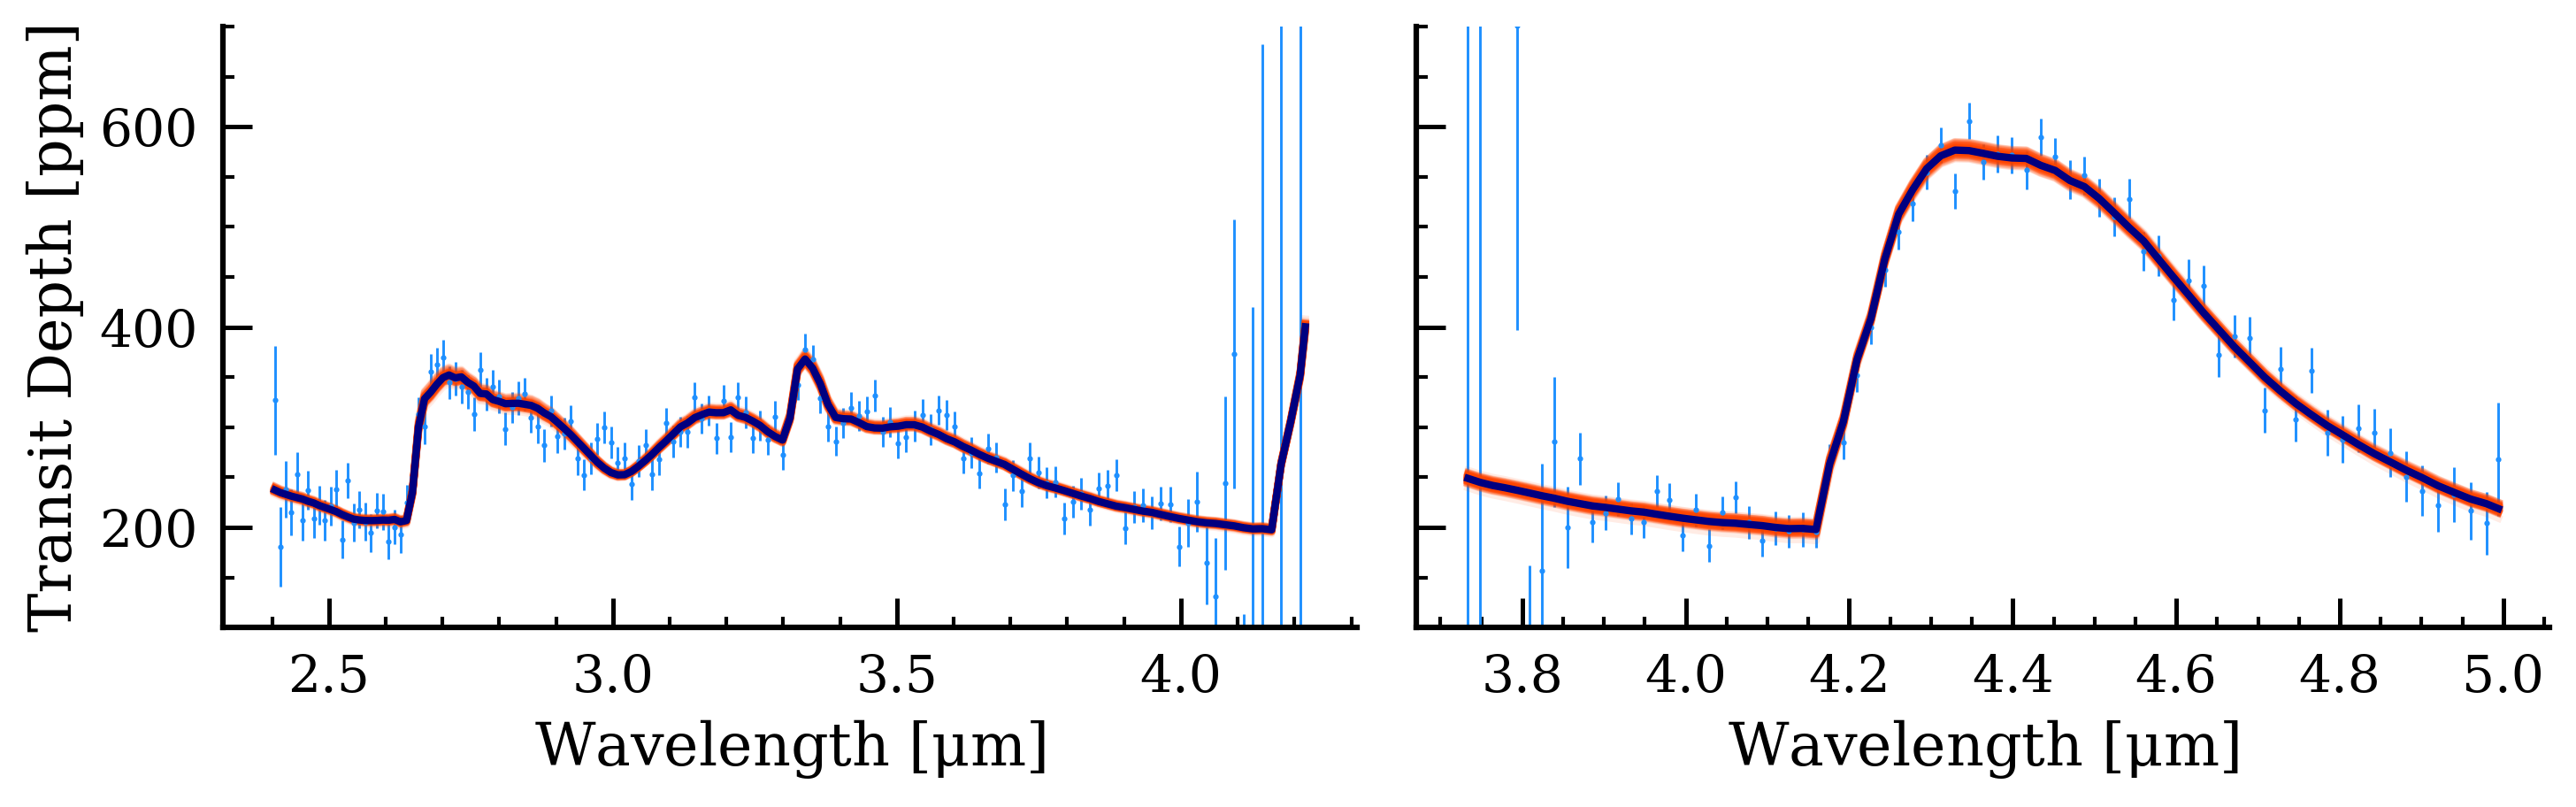

In [6]:
# ------------------------------------------------------------------
#
#                          Some plots
#
# ------------------------------------------------------------------

# Model
samples = post_samps['posterior_samples']
## Adding fixed parameters to samples
for p in range(len(fixed_params)):
    samples[fixed_params[p]] = fixed_vals[p] * np.ones_like(samples[free_params[0]])

fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5), ncols=2, sharey=True)
instruments = ['F322W2', 'F444W']
for ins in range(len(instruments)):
    # Plotting the data
    axs[ins].errorbar(wav[instruments[ins]], dep[instruments[ins]], yerr=dep_err[instruments[ins]], fmt='.', markersize=1., elinewidth=0.7, color='dodgerblue', label=instruments[ins])

    # Median model
    dep_median, _ = evaluate_model(wav=wav[instruments[ins]], dep=dep[instruments[ins]], dep_err=dep_err[instruments[ins]], spec=specmodel,\
                                   log_co2=np.median(samples['logCO2']), log_ch4=np.median(samples['logCH4']), temp=np.median(samples['temp']),\
                                   offset=np.median(samples['offset_' + instruments[ins]]), wav_res=None, res_func=None)
    axs[ins].plot(wav[instruments[ins]], dep_median, color='navy', label='Median Model', zorder=10)

    # Plotting the model for 100 random samples from the posterior
    for i in tqdm(np.random.randint(0, len(samples['logCO2']), 100)):
        dep_model, _ = evaluate_model(wav=wav[instruments[ins]], dep=dep[instruments[ins]], dep_err=dep_err[instruments[ins]], spec=specmodel,\
                                      log_co2=samples['logCO2'][i], log_ch4=samples['logCH4'][i], temp=samples['temp'][i],\
                                      offset=samples['offset_' + instruments[ins]][i], wav_res=None, res_func=None)
        axs[ins].plot(wav[instruments[ins]], dep_model, color='orangered', alpha=0.1)

    axs[ins].set_xlabel('Wavelength [$\mu$m]')

    if ins == 0:
        axs[ins].set_ylabel('Transit Depth [ppm]')

    axs[ins].set_ylim([100, 700])

plt.tight_layout()
sns.despine()

Corner plot of the fitted parameters:

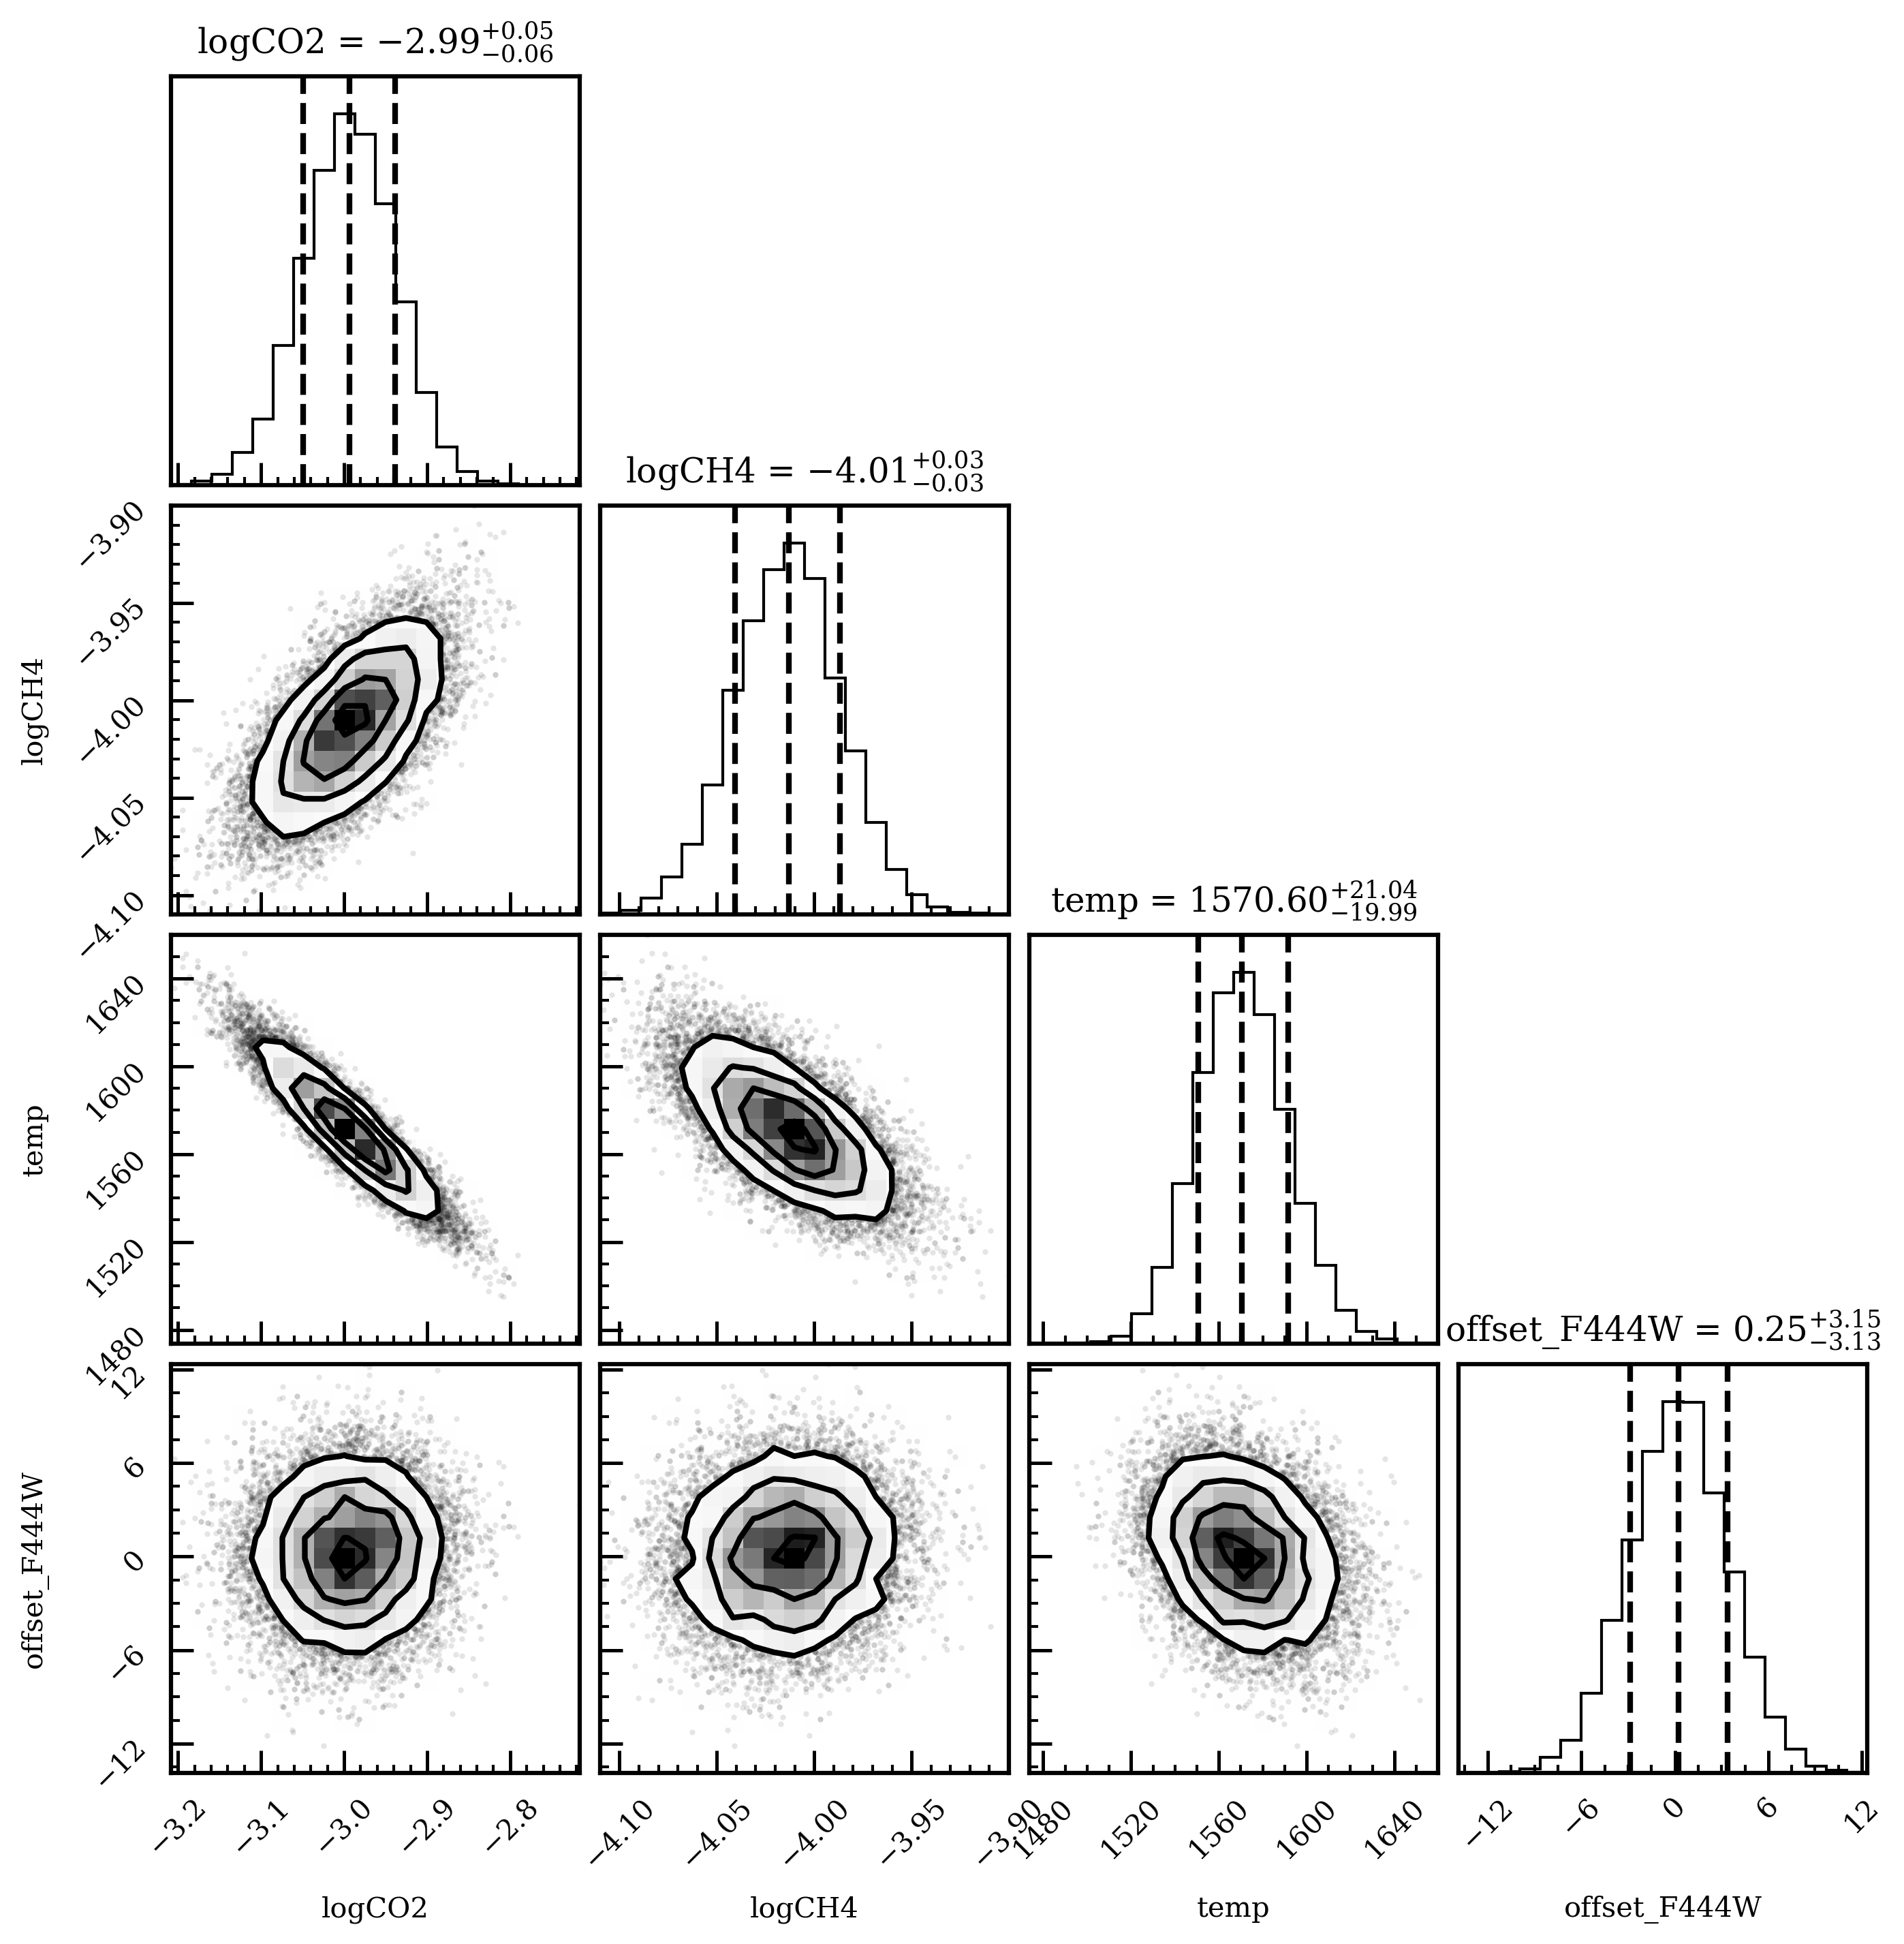

In [7]:
from matplotlib import rcParams
rcParams['font.size'] = 10.
rcParams['axes.labelsize'] = 'medium'
rcParams['xtick.labelsize'] = 'medium'
rcParams['ytick.labelsize'] = 'medium'
rcParams['axes.titlesize'] = 'large'

data = np.vstack([samples['logCO2'], samples['logCH4'], samples['temp'], samples['offset_F444W']]).T
figure = corner.corner(data, labels=free_params, quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.2f', title_kwargs={"fontsize": 12})